# Chapter 3 — Linear Systems and Gauss–Jordan Elimination

Numerical companion to `notes.md`. We'll:

1. Build a coffee-blend system and solve it three ways: by hand-trace, by `numpy.linalg.solve`, and by our own from-scratch RREF function.
2. Walk through Gauss–Jordan step by step on a 3×3 system, printing the matrix after each elementary row operation.
3. Visualize the three outcomes (unique / inconsistent / infinitely many) for 2×2 systems as intersecting lines.
4. See the column picture come alive: the same system as a linear combination of column vectors.
5. Detect outcomes from `rank(A)` vs `rank([A|b])` (Rouché–Capelli) without ever asking for the answer.
6. End with a mini-project: solve a polynomial-fit linear system (Vandermonde) for a quadratic through three points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. The coffee-blend problem

From `notes.md` §3.0:

```
0.5 x  +  0.4 y  +  0.3 z  =  30   (Brazil)
0.3 x  +  0.4 y  +  0.3 z  =  25   (Ethiopia)
0.2 x  +  0.2 y  +  0.4 z  =  20   (Colombia)
```

Solved by hand: `x = y = z = 25` bags.

Let's verify with NumPy.

In [2]:
A = np.array([
    [0.5, 0.4, 0.3],
    [0.3, 0.4, 0.3],
    [0.2, 0.2, 0.4],
])
b = np.array([30.0, 25.0, 20.0])

x = np.linalg.solve(A, b)
print('Solution (Morning, Afternoon, Evening) bags:', x)
print('Check  A @ x =', A @ x, '(should equal b =', b, ')')

Solution (Morning, Afternoon, Evening) bags: [25. 25. 25.]
Check  A @ x = [30. 25. 20.] (should equal b = [30. 25. 20.] )


## 2. Gauss–Jordan from scratch

`np.linalg.solve` is a black box. Let's open it. Below is a from-scratch implementation of Gauss–Jordan elimination that mirrors the six-step procedure in §3.6 of the notes. We'll print the augmented matrix after each operation.

Two functions:

- `rref(M)` — silent, returns the RREF.
- `rref_trace(M)` — same, but prints each elementary row operation as it happens. Use this for learning.

In [3]:
def rref(M, tol=1e-10):
    A = M.astype(float).copy()
    m, n = A.shape
    pivot_row = 0
    for col in range(n):
        if pivot_row >= m:
            break
        # find row with largest absolute value in this column (numerical stability)
        sub = np.abs(A[pivot_row:, col])
        rel = int(np.argmax(sub))
        if sub[rel] < tol:
            continue            # whole column below pivot row is zero, skip
        target = pivot_row + rel
        if target != pivot_row:
            A[[pivot_row, target]] = A[[target, pivot_row]]
        A[pivot_row] = A[pivot_row] / A[pivot_row, col]   # make pivot = 1
        for r in range(m):
            if r != pivot_row and abs(A[r, col]) > tol:
                A[r] = A[r] - A[r, col] * A[pivot_row]
        pivot_row += 1
    return A

def rref_trace(M, tol=1e-10):
    A = M.astype(float).copy()
    m, n = A.shape
    print('Start:')
    print(A); print()
    pivot_row = 0
    for col in range(n):
        if pivot_row >= m: break
        sub = np.abs(A[pivot_row:, col])
        rel = int(np.argmax(sub))
        if sub[rel] < tol: continue
        target = pivot_row + rel
        if target != pivot_row:
            print(f'Swap R{pivot_row+1} <-> R{target+1}')
            A[[pivot_row, target]] = A[[target, pivot_row]]
            print(A); print()
        piv = A[pivot_row, col]
        if abs(piv - 1.0) > tol:
            print(f'R{pivot_row+1} <- R{pivot_row+1} / {piv:g}')
            A[pivot_row] = A[pivot_row] / piv
            print(A); print()
        for r in range(m):
            if r != pivot_row and abs(A[r, col]) > tol:
                factor = A[r, col]
                print(f'R{r+1} <- R{r+1} - ({factor:g}) * R{pivot_row+1}')
                A[r] = A[r] - factor * A[pivot_row]
                print(A); print()
        pivot_row += 1
    return A

### 2.1 Trace the algorithm on the worked example from §3.6

Solve

```
x +  y +  z = 6
2x +  y + 3z = 14
x + 4y + 9z = 36
```

Build `[A | b]` and watch every step.

In [4]:
M = np.array([
    [1, 1, 1, 6],
    [2, 1, 3, 14],
    [1, 4, 9, 36],
])
R = rref_trace(M)
print('Final RREF:')
print(R)
print('\nReading off the answer: x, y, z =', R[:, -1])
print('Compared with notes.md (Example 2): 16/11, 14/11, 36/11 =',
      np.array([16/11, 14/11, 36/11]))

Start:
[[ 1.  1.  1.  6.]
 [ 2.  1.  3. 14.]
 [ 1.  4.  9. 36.]]

Swap R1 <-> R2
[[ 2.  1.  3. 14.]
 [ 1.  1.  1.  6.]
 [ 1.  4.  9. 36.]]

R1 <- R1 / 2
[[ 1.   0.5  1.5  7. ]
 [ 1.   1.   1.   6. ]
 [ 1.   4.   9.  36. ]]

R2 <- R2 - (1) * R1
[[ 1.   0.5  1.5  7. ]
 [ 0.   0.5 -0.5 -1. ]
 [ 1.   4.   9.  36. ]]

R3 <- R3 - (1) * R1
[[ 1.   0.5  1.5  7. ]
 [ 0.   0.5 -0.5 -1. ]
 [ 0.   3.5  7.5 29. ]]

Swap R2 <-> R3
[[ 1.   0.5  1.5  7. ]
 [ 0.   3.5  7.5 29. ]
 [ 0.   0.5 -0.5 -1. ]]

R2 <- R2 / 3.5
[[ 1.      0.5     1.5     7.    ]
 [ 0.      1.      2.1429  8.2857]
 [ 0.      0.5    -0.5    -1.    ]]

R1 <- R1 - (0.5) * R2
[[ 1.      0.      0.4286  2.8571]
 [ 0.      1.      2.1429  8.2857]
 [ 0.      0.5    -0.5    -1.    ]]

R3 <- R3 - (0.5) * R2
[[ 1.      0.      0.4286  2.8571]
 [ 0.      1.      2.1429  8.2857]
 [ 0.      0.     -1.5714 -5.1429]]

R3 <- R3 / -1.57143
[[ 1.      0.      0.4286  2.8571]
 [ 0.      1.      2.1429  8.2857]
 [-0.     -0.      1.      3.2727]]

R

## 3. The three outcomes — plotted in 2D

Each linear equation in two unknowns is a line. Two lines have one of three relationships: cross at one point, are parallel-and-distinct, or coincide. These are exactly the three solution outcomes of §3.3.

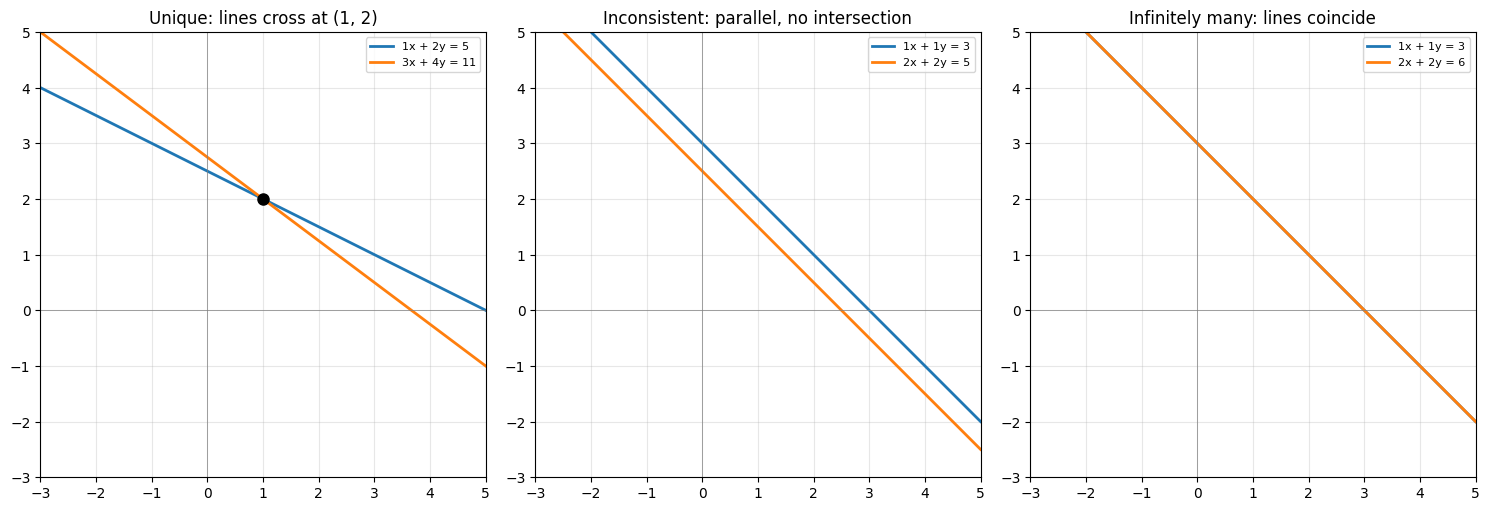

In [5]:
def plot_2x2(ax, A, b, title):
    xs = np.linspace(-3, 5, 200)
    for i in range(2):
        a1, a2 = A[i]
        if abs(a2) > 1e-10:
            ys = (b[i] - a1 * xs) / a2
            ax.plot(xs, ys, lw=2, label=f'{a1:g}x + {a2:g}y = {b[i]:g}')
        else:
            xv = b[i] / a1
            ax.axvline(xv, lw=2, label=f'{a1:g}x = {b[i]:g}')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-3, 5); ax.set_ylim(-3, 5)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(title); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) unique
plot_2x2(axes[0],
         np.array([[1, 2], [3, 4]]), np.array([5, 11]),
         'Unique: lines cross at (1, 2)')
axes[0].plot(1, 2, 'ko', ms=8)

# (b) inconsistent
plot_2x2(axes[1],
         np.array([[1, 1], [2, 2]]), np.array([3, 5]),
         'Inconsistent: parallel, no intersection')

# (c) infinitely many (same line)
plot_2x2(axes[2],
         np.array([[1, 1], [2, 2]]), np.array([3, 6]),
         'Infinitely many: lines coincide')

plt.tight_layout(); plt.show()

### 3.1 Detect outcomes via rank (Rouché–Capelli)

From §3.10:

- `rank(A) < rank([A|b])` → **inconsistent**.
- `rank(A) = rank([A|b]) = n` → **unique**.
- `rank(A) = rank([A|b]) < n` → **infinitely many** (`n - rank(A)` free variables).

We can implement this directly by counting pivots in the RREF — no need to compute the answer first.

In [6]:
def count_pivots(R, tol=1e-10):
    return sum(1 for row in R if np.any(np.abs(row) > tol))

def classify(A, b, tol=1e-10):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1, 1)
    rank_A = count_pivots(rref(A))
    rank_aug = count_pivots(rref(np.hstack([A, b])))
    n = A.shape[1]
    if rank_aug > rank_A:
        return f'Inconsistent (rank(A)={rank_A}, rank([A|b])={rank_aug})'
    if rank_A == n:
        return f'Unique solution (rank={rank_A}={n})'
    return f'Infinitely many; {n - rank_A} free variable(s) (rank={rank_A} < n={n})'

tests = [
    (np.array([[1, 2], [3, 4]]),       np.array([5, 11]),  'cross at (1, 2)'),
    (np.array([[1, 1], [2, 2]]),       np.array([3, 5]),    'parallel'),
    (np.array([[1, 1], [2, 2]]),       np.array([3, 6]),    'same line'),
    (np.array([[1, 2, 3], [2, 4, 6]]), np.array([6, 12]),  'rank-1 system'),
]
for A, b, lbl in tests:
    print(f'{lbl:18s} -> {classify(A, b)}')

cross at (1, 2)    -> Unique solution (rank=2=2)
parallel           -> Inconsistent (rank(A)=1, rank([A|b])=2)
same line          -> Infinitely many; 1 free variable(s) (rank=1 < n=2)
rank-1 system      -> Infinitely many; 2 free variable(s) (rank=1 < n=3)


## 4. The column picture

Same 2×2 system

```
x + 2y = 5
3x + 4y = 11
```

Row picture (above): two lines crossing at `(1, 2)`.

Column picture: we want scalars `(x, y)` such that

```
x · (1, 3)  +  y · (2, 4)  =  (5, 11)
```

Visualise the two columns being added tip-to-tail — with `(x, y) = (1, 2)`.

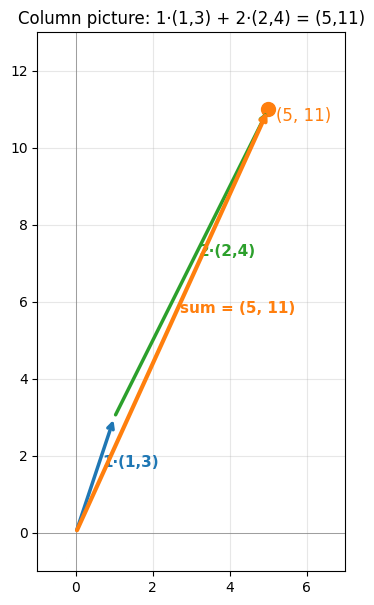

In [7]:
def draw_arrow(ax, tail, head, color, label=None, lw=2.5):
    ax.annotate('', xy=head, xytext=tail,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label is not None:
        mid = (np.array(tail) + np.array(head)) / 2
        ax.annotate(label, xy=mid + np.array([0.2, 0.2]),
                    color=color, fontsize=11, fontweight='bold')

fig, ax = plt.subplots(figsize=(7, 7))
c1 = np.array([1, 3])     # column 1
c2 = np.array([2, 4])     # column 2
x_sol, y_sol = 1, 2

# 1*c1 from origin
p0 = np.zeros(2)
p1 = p0 + x_sol * c1
p2 = p1 + y_sol * c2

draw_arrow(ax, p0, p1, 'tab:blue',  '1·(1,3)')
draw_arrow(ax, p1, p2, 'tab:green', '2·(2,4)')
draw_arrow(ax, p0, p2, 'tab:orange', 'sum = (5, 11)', lw=3)

ax.plot(*p2, 'o', color='tab:orange', ms=10)
ax.text(p2[0] + 0.2, p2[1] - 0.3, '(5, 11)', color='tab:orange', fontsize=12)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-1, 7); ax.set_ylim(-1, 13)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Column picture: 1·(1,3) + 2·(2,4) = (5,11)')
plt.show()

## 5. Three planes in 3D — unique intersection

Each equation in 3 unknowns is a plane in ℝ³. A consistent unique system corresponds to three planes meeting in a single point. Plot the system from `notes.md` §3.6 (worked example):

```
x + 2y +  z = 5
2x + 5y + 3z = 13
x +  y -  z = 0
```

with answer `(1, 1, 2)`.

Unique solution: [1. 1. 2.]


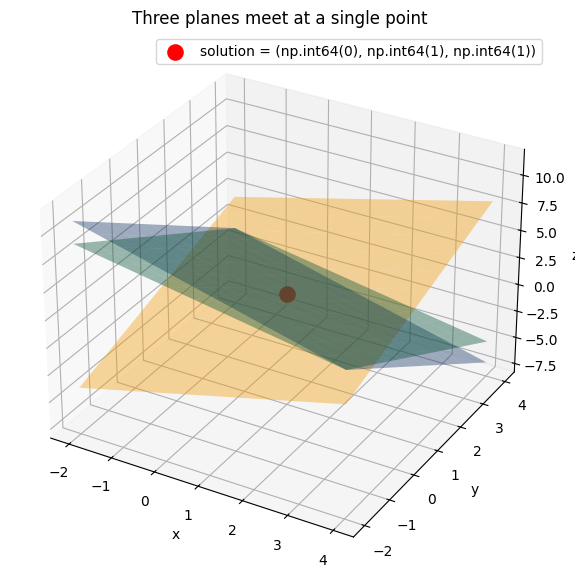

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

A = np.array([[1, 2, 1], [2, 5, 3], [1, 1, -1]], dtype=float)
b = np.array([5, 13, 0], dtype=float)
sol = np.linalg.solve(A, b)
print('Unique solution:', sol)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

xs = np.linspace(-2, 4, 12)
ys = np.linspace(-2, 4, 12)
X, Y = np.meshgrid(xs, ys)

colors = ['#3b82f6', '#10b981', '#f59e0b']
for i, (a_row, bi, col) in enumerate(zip(A, b, colors)):
    a1, a2, a3 = a_row
    Z = (bi - a1 * X - a2 * Y) / a3
    ax.plot_surface(X, Y, Z, alpha=0.4, color=col,
                    edgecolor='none')

ax.scatter(*sol, color='red', s=120, label=f'solution = {tuple(sol.astype(int))}')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Three planes meet at a single point')
ax.legend()
plt.show()

## 6. Parametric solutions — plotting a 1-parameter family

Take Example 4 from `worked-examples.md`:

```
x  +  2y  -    z  =  4
2x  +  4y  +  3z  =  18
x  +  2y  +  4z  =  14
```

Solution set: `(x, y, z) = (6, 0, 2) + t · (-2, 1, 0)`.

We can verify the parametric form numerically by sampling many `t`'s and confirming each satisfies all three original equations.

Across 50 values of t in [-2, 2], max | A x - b | = 8.88e-16


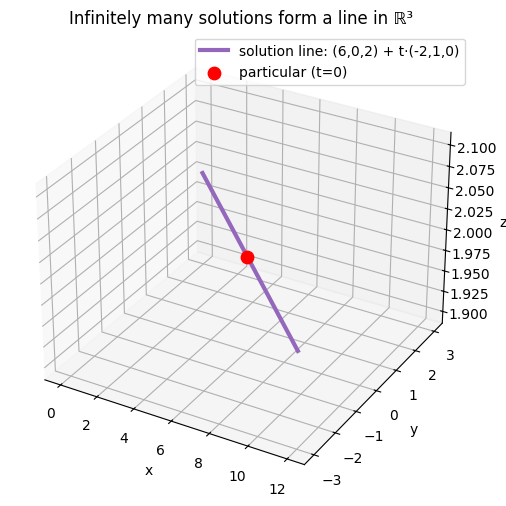

In [9]:
A_param = np.array([[1, 2, -1], [2, 4, 3], [1, 2, 4]], dtype=float)
b_param = np.array([4, 18, 14], dtype=float)

x_p = np.array([6, 0, 2])      # particular
h   = np.array([-2, 1, 0])     # homogeneous direction

# Sample 50 values of t, confirm A x = b for every one
ts = np.linspace(-2, 2, 50)
max_err = 0.0
for t in ts:
    x = x_p + t * h
    err = np.max(np.abs(A_param @ x - b_param))
    max_err = max(max_err, err)
print(f'Across 50 values of t in [-2, 2], max | A x - b | = {max_err:.2e}')

# Plot the line of solutions in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
line = np.array([x_p + t * h for t in np.linspace(-3, 3, 100)])
ax.plot(line[:, 0], line[:, 1], line[:, 2], lw=3, color='tab:purple',
        label='solution line: (6,0,2) + t·(-2,1,0)')
ax.scatter(*x_p, color='red', s=80, label='particular (t=0)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Infinitely many solutions form a line in ℝ³')
ax.legend(); plt.show()

## 7. Floating-point caution — ill-conditioned systems

On paper, `rank` is exact: a row is either zero or it isn't. In floating-point arithmetic, a row that's *nearly* zero (e.g. `1e-15`) might be due to roundoff or a true near-singularity. Beware.

The classic example is the **Hilbert matrix** `H[i, j] = 1 / (i + j + 1)` — wildly ill-conditioned. NumPy will happily "solve" `H x = b`, but the answer can be junk for `n ≥ 12` or so.

In [10]:
for n in [4, 8, 12, 14]:
    H = np.array([[1.0/(i + j + 1) for j in range(n)] for i in range(n)])
    x_true = np.ones(n)
    b = H @ x_true
    x_solved = np.linalg.solve(H, b)
    err = np.max(np.abs(x_solved - x_true))
    cond = np.linalg.cond(H)
    print(f'n={n:2d}  cond(H)={cond:.2e}  max error in solution = {err:.2e}')

n= 4  cond(H)=1.55e+04  max error in solution = 5.00e-14
n= 8  cond(H)=1.53e+10  max error in solution = 1.61e-07
n=12  cond(H)=1.72e+16  max error in solution = 2.20e-01
n=14  cond(H)=4.05e+17  max error in solution = 8.18e+00


## 8. Mini-project — fitting a quadratic by solving a linear system

Polynomial fitting is *itself* a linear algebra problem. Suppose we want a quadratic

```
p(x) = a + b x + c x²
```

passing through three given points `(x₁, y₁), (x₂, y₂), (x₃, y₃)`. Plugging each point into `p` gives:

```
1 + b x₁ + c x₁² = y₁      (when a is the intercept)
...
```

Or, more cleanly: stack the unknowns as `(a, b, c)` and write the **Vandermonde system** `V · (a, b, c)ᵀ = (y₁, y₂, y₃)ᵀ`:

```
    [ 1   x₁   x₁² ] [ a ]   [ y₁ ]
    [ 1   x₂   x₂² ] [ b ] = [ y₂ ]
    [ 1   x₃   x₃² ] [ c ]   [ y₃ ]
```

A 3×3 linear system that we now know how to solve. Let's fit a quadratic through `(0, 1)`, `(1, 4)`, `(2, 9)` (which is, secretly, `1 + 2x + x² = (1+x)²`).

Vandermonde matrix V:
[[1. 0. 0.]
 [1. 1. 1.]
 [1. 2. 4.]]

Fitted quadratic: p(x) = 1 + 2·x + 1·x²


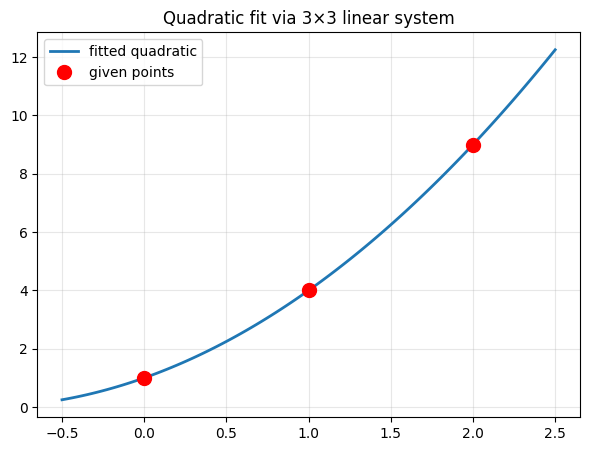

In [11]:
pts = np.array([(0, 1), (1, 4), (2, 9)], dtype=float)
xs, ys = pts[:, 0], pts[:, 1]

V = np.vander(xs, 3, increasing=True)   # columns: 1, x, x^2
print('Vandermonde matrix V:')
print(V)

coef = np.linalg.solve(V, ys)
print(f'\nFitted quadratic: p(x) = {coef[0]:g} + {coef[1]:g}·x + {coef[2]:g}·x²')

# plot
xx = np.linspace(-0.5, 2.5, 100)
yy = coef[0] + coef[1]*xx + coef[2]*xx**2
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xx, yy, 'tab:blue', lw=2, label='fitted quadratic')
ax.plot(xs, ys, 'ro', ms=10, label='given points')
ax.grid(alpha=0.3); ax.legend(); ax.set_title('Quadratic fit via 3×3 linear system')
plt.show()

## Takeaways

- Gauss–Jordan reduces any matrix to a unique RREF; reading the answer is just reading rows.
- The same algorithm reveals all three outcomes — unique, inconsistent, infinitely many — with no special-case logic.
- The **column picture** (`Ax` = combination of A's columns) and the **row picture** (intersection of hyperplanes) are two views of the same equation. The column picture scales to high dimensions; the row picture only helps in ℝ² / ℝ³.
- Many seemingly unrelated problems — polynomial fits, balanced chemical equations, network flows — are linear systems in disguise. Once you can solve `Ax = b`, you can solve all of them.